# Revised batch consumer-resource simulations

Self-contained notebook: no model.py import is required. Run all cells in order. Time and concentrations are normalized. Compare baseline, affinity, starvation, both and a structured scenario. Full equations and assumptions are in model_guide.pdf and README.md. The first code cell embeds the exact reusable scripts supplied with this notebook.

In [1]:
import sys, types
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Image
model_source = '"""Energy-accounted, well-mixed batch consumer-resource model."""\nfrom dataclasses import dataclass, asdict\nimport numpy as np\nimport pandas as pd\nfrom scipy.integrate import solve_ivp\nfrom scipy.stats import truncnorm\n\n@dataclass\nclass Config:\n    variable_affinity: bool = True\n    starvation_mortality: bool = True\n    structured_community: bool = False\n    affinity_log_sd: float = .7\n    starvation_mean: float = .06\n    starvation_sd: float = .015\n    seed: int = 42\n    n_species: int = 25\n    t_end: float = 300.\n    n_times: int = 1201\n    growth_mean: float = .5\n    growth_sd: float = .15\n    growth_reference: float = 1.\n    death_mean: float = .01\n    death_sd: float = .003\n    initial_biomass: float = .01\n    initial_resource: float = 1.\n    half_saturation: float = .1\n    leakage: float = .2\n    extinction_fraction: float = 1e-6\n\nFOODS = [\'R0\', \'M1\', \'M2\']\ndef truncated(rng, mean, sd, low, high, size):\n    return truncnorm.rvs((low-mean)/sd, (high-mean)/sd, loc=mean, scale=sd,\n                         size=size, random_state=rng)\n\ndef generate(c=Config()):\n    if c.n_species < 3 or c.n_times < 2 or c.t_end <= 0:\n        raise ValueError(\'Require >=3 species, >=2 output times, and positive duration\')\n    if not (0 <= c.leakage < 1 and 0 < c.extinction_fraction < 1):\n        raise ValueError(\'Require 0<=leakage<1 and 0<extinction_fraction<1\')\n    if min(c.growth_sd,c.death_sd,c.growth_reference,c.initial_biomass,c.half_saturation) <= 0 or c.initial_resource < 0:\n        raise ValueError(\'Invalid positive scale or initial resource\')\n    rng = np.random.default_rng(c.seed)\n    score = truncated(rng,c.growth_mean,c.growth_sd,0,1,c.n_species)\n    death = truncated(rng,c.death_mean,c.death_sd,0,np.inf,c.n_species)\n    # Sample uniformly among the seven nonempty food subsets. Guarantee coverage.\n    codes = rng.integers(1,8,c.n_species)\n    if c.n_species >= 3: codes[:3] = [1,2,4]\n    mask = ((codes[:,None] >> np.arange(3)) & 1).astype(bool)\n    weights = rng.dirichlet(np.ones(3),c.n_species)*mask\n    weights /= weights.sum(axis=1,keepdims=True)\n    # Retained energy fractions: R0 leaks, metabolites do not.\n    retain = np.array([1-c.leakage,1.,1.])\n    # Normalize capacity so growth at saturation of all permitted foods is mu_max.\n    capacity = score*c.growth_reference/(weights@retain)\n    uptake = capacity[:,None]*weights\n    split = rng.dirichlet([1.,1.],c.n_species)\n    # Extra draws use an independent generator so original community draws stay fixed.\n    extra = np.random.default_rng(c.seed + 100000)\n    Kdraw = extra.lognormal(np.log(c.half_saturation),c.affinity_log_sd,(c.n_species,3))\n    Kdraw = np.clip(Kdraw,.01,1.)\n    starve_draw = truncated(extra,c.starvation_mean,c.starvation_sd,0,.15,c.n_species)\n    biomass_draw = extra.lognormal(0,1.,c.n_species)\n    # Optional joint scenario: 70% specialists, 20% two-food users, 10% generalists.\n    if c.structured_community:\n        sizes=extra.choice([1,2,3],c.n_species,p=[.7,.2,.1])\n        mask=np.zeros((c.n_species,3),dtype=bool)\n        for i,k in enumerate(sizes): mask[i,extra.choice(3,k,replace=False)]=True\n        mask[:3]=np.eye(3,dtype=bool)\n        weights=extra.dirichlet(np.ones(3),c.n_species)*mask\n        weights/=weights.sum(axis=1,keepdims=True)\n        types=extra.choice([0,1,2,3],c.n_species,p=[.25,.25,.25,.25])\n        types[0]=3 # guarantee an R0 consumer that produces both metabolites\n        leak=np.where(types==0,0.,c.leakage)\n        split=extra.dirichlet([1.,1.],c.n_species)\n        split[types==1]=[1.,0.];split[types==2]=[0.,1.]\n    else: leak=np.full(c.n_species,c.leakage)\n    retain=np.column_stack([1-leak,np.ones((c.n_species,2))])\n    capacity=score*c.growth_reference/np.sum(weights*retain,axis=1)\n    uptake=capacity[:,None]*weights\n    initial=c.initial_biomass*biomass_draw/biomass_draw.sum() if c.structured_community else np.full(c.n_species,c.initial_biomass/c.n_species)\n    K=Kdraw if c.variable_affinity else np.full_like(Kdraw,c.half_saturation)\n    starve=starve_draw if c.starvation_mortality else np.zeros(c.n_species)\n    table = pd.DataFrame({\'species\':[f\'S{i+1:02d}\' for i in range(c.n_species)],\n        \'growth_score\':score,\'mu_max\':score*c.growth_reference,\'death_rate\':death,\n        \'total_uptake_capacity\':capacity,\'M1_secretion_share\':split[:,0],\n        \'M2_secretion_share\':split[:,1], \'initial_biomass\':initial, \'starvation_death_increment\':starve, \'leakage_fraction\':leak})\n    for j,f in enumerate(FOODS):\n        table[f\'can_consume_{f}\']=mask[:,j]\n        table[f\'K_{f}\']=K[:,j]\n        table[f\'preference_{f}\']=weights[:,j]\n        table[f\'uptake_max_{f}\']=uptake[:,j]\n    return {\'config\':c,\'table\':table,\'uptake\':uptake,\'split\':split,\'retain\':retain,\'K\':K,\'leak\':leak,\'initial\':initial,\'starve\':starve}\n\ndef fluxes(N,R,p):\n    c=p[\'config\']\n    u=p[\'uptake\']*np.maximum(R,0)/(p[\'K\']+np.maximum(R,0))\n    gross=np.sum(u*p[\'retain\'],axis=1)\n    consumed=np.maximum(N,0)[:,None]*u\n    secretion=np.sum(consumed[:,0,None]*p[\'leak\'][:,None]*p[\'split\'],axis=0)\n    return gross,consumed,secretion\n\ndef death_rates(gross,p):\n    fraction=np.clip(gross/np.maximum(p[\'table\'].mu_max.to_numpy(),1e-300),0,1)\n    return p[\'table\'].death_rate.to_numpy()+p[\'starve\']*(1-fraction)\n\ndef simulate(p):\n    c=p[\'config\']; n=c.n_species; death=p[\'table\'].death_rate.to_numpy()\n    N0=p[\'initial\']; cutoff=c.initial_biomass/n*c.extinction_fraction\n    # State: N, R0/M1/M2, cumulative mortality, biomass removed at cutoffs.\n    y=np.r_[N0,c.initial_resource,0.,0.,0.,0.]\n    active=np.ones(n,dtype=bool); extinction=np.full(n,np.nan)\n    times=np.linspace(0,c.t_end,c.n_times); states=np.empty((len(times),n+5))\n    t=0.; filled=np.zeros(len(times),dtype=bool)\n    while t < c.t_end:\n        def rhs(t,y):\n            N=np.maximum(y[:n],0)*active; R=y[n:n+3]\n            gross,consumed,secreted=fluxes(N,R,p)\n            death=death_rates(gross,p)\n            return np.r_[N*(gross-death),-consumed.sum(axis=0)+np.r_[0.,secreted],\n                         N@death,0.]\n        events=[]; ids=np.flatnonzero(active)\n        for i in ids:\n            def event(t,y,i=i): return y[i]-cutoff\n            event.terminal=True; event.direction=-1; events.append(event)\n        sol=solve_ivp(rhs,(t,c.t_end),y,method=\'DOP853\',rtol=1e-8,atol=1e-13,\n                      dense_output=True,events=events or None,max_step=2.)\n        if not sol.success: raise RuntimeError(sol.message)\n        end=sol.t[-1]; sel=(times>=t)&(times<=end)&(~filled)\n        if sel.any():\n            states[sel]=sol.sol(times[sel]).T; filled[sel]=True\n        y=sol.y[:,-1].copy(); t=end\n        if t>=c.t_end: break\n        hits=[ids[k] for k,e in enumerate(sol.t_events) if len(e)]\n        hits=list(set(hits+list(np.flatnonzero(active & (y[:n]<=cutoff*(1+1e-8))))))\n        if not hits: raise RuntimeError(\'Extinction event without a crossing\')\n        y[-1]+=y[hits].sum(); y[hits]=0; active[hits]=False; extinction[hits]=t\n    assert filled.all()\n    N=np.maximum(states[:,:n],0); R=np.maximum(states[:,n:n+3],0)\n    gross=np.array([fluxes(N[k],R[k],p)[0] for k in range(len(times))])\n    deaths=np.array([death_rates(g,p) for g in gross])\n    result={\'t\':times,\'N\':N,\'R\':R,\'gross\':gross,\'net\':gross-deaths,\'death_rates\':deaths,\n            \'mortality\':N*deaths,\'extinction\':extinction,\'death_loss\':states[:,-2],\n            \'cutoff_loss\':states[:,-1],\'cutoff\':cutoff}\n    budget=N.sum(axis=1)+R.sum(axis=1)+states[:,-2]+states[:,-1]\n    result[\'budget_error\']=budget-(c.initial_biomass+c.initial_resource)\n    assert np.max(np.abs(result[\'budget_error\']))<1e-6\n    assert states[:,:n+3].min()>-1e-9\n    return result\n\ndef summarize(p,r):\n    df=p[\'table\'].copy(); df[\'final_biomass\']=r[\'N\'][-1]\n    df[\'peak_biomass\']=r[\'N\'].max(axis=0)\n    df[\'biomass_time_integral\']=np.trapz(r[\'N\'],r[\'t\'],axis=0)\n    df[\'extinction_time\']=r[\'extinction\']; df[\'survived\']=np.isnan(r[\'extinction\'])\n    df[\'final_percent\']=100*r[\'N\'][-1]/max(r[\'N\'][-1].sum(),1e-300)\n    return df\n\ndef export(p,r,out):\n    from pathlib import Path\n    import json\n    out=Path(out);out.mkdir(parents=True,exist_ok=True)\n    summarize(p,r).to_csv(out/\'species_summary.csv\',index=False)\n    frames=[]\n    for i,name in enumerate(p[\'table\'].species):\n        frames.append(pd.DataFrame({\'time\':r[\'t\'],\'species\':name,\'biomass\':r[\'N\'][:,i],\n          \'percent\':100*r[\'N\'][:,i]/np.maximum(r[\'N\'].sum(axis=1),1e-300),\n          \'gross_growth_rate\':r[\'gross\'][:,i],\'death_rate\':r[\'death_rates\'][:,i],\n          \'net_growth_rate\':r[\'net\'][:,i], \'biomass_death_flux\':r[\'mortality\'][:,i]}))\n    pd.concat(frames).to_csv(out/\'species_timeseries.csv\',index=False)\n    pd.DataFrame({\'time\':r[\'t\'],**{f:r[\'R\'][:,j] for j,f in enumerate(FOODS)},\n      \'total_biomass\':r[\'N\'].sum(axis=1),\'cumulative_death_loss\':r[\'death_loss\'],\n      \'cumulative_cutoff_loss\':r[\'cutoff_loss\'],\'budget_error\':r[\'budget_error\']}).to_csv(out/\'community_timeseries.csv\',index=False)\n    (out/\'config.json\').write_text(json.dumps(asdict(p[\'config\']),indent=2))\n'
analysis_source = '"""Matched scenario comparisons and captions."""\nfrom pathlib import Path\nfrom dataclasses import replace\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom model import Config,generate,simulate,summarize,export,FOODS\n\nSCENARIOS={\n \'baseline\':dict(variable_affinity=False,starvation_mortality=False,structured_community=False),\n \'affinity\':dict(variable_affinity=True,starvation_mortality=False,structured_community=False),\n \'starvation\':dict(variable_affinity=False,starvation_mortality=True,structured_community=False),\n \'both\':dict(variable_affinity=True,starvation_mortality=True,structured_community=False),\n \'structured\':dict(variable_affinity=True,starvation_mortality=True,structured_community=True)}\n\ndef diversity(r):\n    total=r[\'N\'].sum(axis=1);alive=total>0\n    shares=np.divide(r[\'N\'],total[:,None],out=np.zeros_like(r[\'N\']),where=total[:,None]>0)\n    H=-np.sum(shares*np.log(np.maximum(shares,1e-300)),axis=1);H[~alive]=np.nan\n    effective=np.exp(H);richness=(r[\'N\']>0).sum(axis=1)\n    return pd.DataFrame({\'time\':r[\'t\'],\'total_biomass\':total,\'shannon\':H,\'effective_species\':effective,\'richness\':richness})\n\ndef run_scenarios(config=Config(),out=\'outputs\'):\n    root=Path(out);root.mkdir(exist_ok=True,parents=True);runs={};rows=[]\n    for name,settings in SCENARIOS.items():\n        p=generate(replace(config,**settings));r=simulate(p);runs[name]=(p,r)\n        folder=root/name;export(p,r,folder);d=diversity(r);d.to_csv(folder/\'diversity_timeseries.csv\',index=False)\n        p[\'table\'].select_dtypes(include=\'number\').describe().T.to_csv(folder/\'realized_parameter_spread.csv\')\n        df=summarize(p,r);rows.append({\'scenario\':name,\'survivors\':int(df.survived.sum()),\'final_biomass\':r[\'N\'][-1].sum(),\'final_shannon\':d.shannon.iloc[-1],\'max_budget_error\':abs(r[\'budget_error\']).max()})\n    summary=pd.DataFrame(rows);summary.to_csv(root/\'scenario_summary.csv\',index=False)\n    return runs,summary\n\ndef make_figures(runs,out=\'outputs\'):\n    out=Path(out);figures=[];plt.rcParams.update({\'figure.dpi\':120,\'axes.spines.top\':False,\'axes.spines.right\':False})\n    def save(fig,name,caption):\n        fig.tight_layout();path=out/(name+\'.png\');fig.savefig(path,bbox_inches=\'tight\');plt.close(fig);figures.append((path,caption))\n    fig,axs=plt.subplots(2,2,figsize=(11,7))\n    for name,(p,r) in runs.items():\n        d=diversity(r)\n        for ax,col in zip(axs.flat,[\'shannon\',\'effective_species\',\'richness\',\'total_biomass\']):ax.plot(d.time,d[col],label=name);ax.set(xlabel=\'Time\',ylabel=col.replace(\'_\',\' \'))\n    axs[0,0].legend(fontsize=8);axs[1,1].set_yscale(\'log\')\n    save(fig,\'01_scenario_diversity\',\'Figure 1. Shannon H (natural logarithm), effective diversity exp(H), species remaining above the cutoff, and total living biomass. The first four scenarios share growth, baseline death, permissions, secretion and initial abundance draws. The structured scenario changes several traits jointly, so its difference cannot be attributed to one mechanism. Shannon is undefined when total biomass is zero.\')\n    p,r=runs[\'both\'];df=p[\'table\'];colors=plt.cm.turbo(np.linspace(0,1,len(df)))\n    fig,axs=plt.subplots(2,3,figsize=(13,8))\n    axs[0,0].hist(df.mu_max,bins=8);axs[0,0].set(xlabel=\'Maximum gross growth\',ylabel=\'Species count\')\n    axs[0,1].scatter(df.death_rate,df.starvation_death_increment);axs[0,1].set(xlabel=\'Baseline mortality\',ylabel=\'Additional starvation mortality\')\n    im=axs[0,2].imshow(p[\'K\'],aspect=\'auto\',norm=plt.matplotlib.colors.LogNorm());fig.colorbar(im,ax=axs[0,2],label=\'Half-saturation K\');axs[0,2].set(xticks=range(3),xticklabels=FOODS,ylabel=\'Species index\')\n    im=axs[1,0].imshow(p[\'uptake\'],aspect=\'auto\');fig.colorbar(im,ax=axs[1,0],label=\'Maximum uptake\');axs[1,0].set(xticks=range(3),xticklabels=FOODS,ylabel=\'Species index\')\n    axs[1,1].bar(range(len(df)),p[\'split\'][:,0],label=\'M1\');axs[1,1].bar(range(len(df)),p[\'split\'][:,1],bottom=p[\'split\'][:,0],label=\'M2\');axs[1,1].legend();axs[1,1].set(xlabel=\'Species index\',ylabel=\'Leaked-energy allocation\')\n    groups=df[[f\'can_consume_{f}\' for f in FOODS]].apply(lambda row:\'+\'.join(f for f,v in zip(FOODS,row) if v),axis=1).value_counts()\n    axs[1,2].barh(groups.index,groups.values);axs[1,2].set(xlabel=\'Species count\',ylabel=\'Permitted foods\')\n    save(fig,\'02_species_traits\',\'Figure 2. Realized traits in the both scenario. Lower K means uptake remains more efficient at low chemical concentration. Maximum uptake is zero for forbidden foods. Growth capacity, death parameters and K were sampled independently; no growth-survival or growth-affinity tradeoff was imposed. Secretion allocations describe potential output when R0 is actually consumed.\')\n    for name in [\'both\',\'structured\']:\n        p,r=runs[name];N=r[\'N\'];t=r[\'t\'];total=N.sum(axis=1)\n        fig,axs=plt.subplots(2,2,figsize=(12,8))\n        for i in range(N.shape[1]):axs[0,0].plot(t,np.maximum(N[:,i],r[\'cutoff\']/10),color=colors[i],lw=.9)\n        axs[0,0].axhline(r[\'cutoff\'],color=\'black\',ls=\'--\');axs[0,0].set(yscale=\'log\',xlabel=\'Time\',ylabel=\'Absolute biomass\')\n        perc=np.divide(100*N,total[:,None],out=np.zeros_like(N),where=total[:,None]>0)\n        axs[0,1].stackplot(t,perc.T,colors=colors);axs[0,1].set(xlabel=\'Time\',ylabel=\'Community percentage\',ylim=(0,100))\n        for j,f in enumerate(FOODS):axs[1,0].plot(t,r[\'R\'][:,j],label=f)\n        axs[1,0].legend();axs[1,0].set(xlabel=\'Time\',ylabel=\'Chemical energy concentration\')\n        for j,f in enumerate(FOODS):axs[1,1].plot(t,r[\'R\'][:,j],label=f)\n        axs[1,1].set(xlabel=\'Time\',ylabel=\'Chemical energy concentration\',xlim=(0,50));axs[1,1].legend()\n        fig.legend(handles=[plt.Line2D([0],[0],color=colors[i],label=f\'S{i+1:02d}\') for i in range(N.shape[1])],loc=\'lower center\',ncol=13,bbox_to_anchor=(.5,-.06),fontsize=7)\n        save(fig,\'03_dynamics_\'+name,f\'Figure 3 ({name}). Species biomass, composition, chemical depletion and an early-time chemical zoom. M1/M2 begin at zero and accumulate only through R0 consumption. Log plots show extinct species at a display floor, not positive simulated biomass. Percentages can rise while absolute biomass falls. Species colors are consistent across these panels.\')\n    p,r=runs[\'both\'];t=r[\'t\'];N=r[\'N\'];fig,axs=plt.subplots(2,2,figsize=(11,7))\n    for i in range(N.shape[1]):\n        for ax,key in zip([axs[0,0],axs[0,1]],[\'gross\',\'death_rates\']):ax.plot(t,np.where(N[:,i]>0,r[key][:,i],np.nan),color=colors[i],lw=.8)\n    axs[0,0].set(xlabel=\'Time\',ylabel=\'Gross per-capita growth\');axs[0,1].set(xlabel=\'Time\',ylabel=\'Per-capita death\')\n    for i in range(N.shape[1]):axs[1,0].plot(t,np.where(N[:,i]>0,r[\'net\'][:,i],np.nan),color=colors[i],lw=.8)\n    axs[1,0].axhline(0,color=\'black\',ls=\'--\');axs[1,0].set(xlabel=\'Time\',ylabel=\'Net per-capita growth\')\n    axs[1,1].plot(t,(N*r[\'gross\']).sum(axis=1),label=\'Growth flux\');axs[1,1].plot(t,r[\'mortality\'].sum(axis=1),label=\'Death flux\');axs[1,1].legend();axs[1,1].set(xlabel=\'Time\',ylabel=\'Biomass / time\')\n    save(fig,\'04_growth_death\',\'Figure 4. Resource-limited gross growth, starvation-dependent mortality, net growth and community biomass fluxes in the both scenario. Death rises toward baseline plus starvation increment as food-supported growth approaches zero. Negative net growth means biomass decreases; it does not mean immediate extinction. Rates after irreversible removal are hidden.\')\n    df=summarize(p,r);fig,axs=plt.subplots(2,2,figsize=(11,7))\n    for ax,x in zip(axs.flat,[\'mu_max\',\'death_rate\',\'starvation_death_increment\',\'K_R0\']):\n        ax.scatter(df[x],np.log10(np.maximum(df.final_biomass,r[\'cutoff\']/10)),c=df.survived.map({True:\'tab:blue\',False:\'tab:red\'}));ax.set(xlabel=x,ylabel=\'log10 final biomass (floor for extinct)\')\n    save(fig,\'05_trait_outcomes\',\'Figure 5. Single-community trait associations: blue species persist above the cutoff, red species were removed. Extinct final biomass is displayed at a floor. K_R0 has no uptake effect for species forbidden from using R0. These plots are descriptive; food permissions and interactions can confound apparent trait effects.\')\n    fig,axs=plt.subplots(1,2,figsize=(11,4))\n    for name,(p,r) in runs.items():\n        axs[0].plot(r[\'t\'],r[\'budget_error\'],label=name)\n        e=np.sort(r[\'extinction\'][np.isfinite(r[\'extinction\'])]);axs[1].step(np.r_[0,e,300],np.r_[0,np.arange(1,len(e)+1),len(e)],where=\'post\',label=name)\n    axs[0].set(xlabel=\'Time\',ylabel=\'Energy-accounting error\');axs[1].set(xlabel=\'Time\',ylabel=\'Cumulative threshold extinctions\');axs[1].legend(fontsize=8)\n    save(fig,\'06_accounting_extinctions\',\'Figure 6. Accounting residuals and cumulative threshold extinctions. Energy-equivalent resources plus living biomass, accumulated mortality and cutoff losses remain equal to the initial total. The extinction curve records numerical cutoff crossings, not experimental viability measurements.\')\n    return figures\n\ndef repeated_scenarios(config=Config(),replicates=10):\n    rows=[]\n    for seed in range(config.seed,config.seed+replicates):\n        for name,settings in SCENARIOS.items():\n            p=generate(replace(config,seed=seed,**settings));r=simulate(p);df=summarize(p,r);df[\'seed\']=seed;df[\'scenario\']=name;df[\'shannon_final\']=diversity(r).shannon.iloc[-1];rows.append(df)\n    return pd.concat(rows,ignore_index=True)\n\ndef repeated_plot(df,out):\n    fig,axs=plt.subplots(1,2,figsize=(11,4))\n    grouped=df.groupby([\'seed\',\'scenario\']).agg(survivors=(\'survived\',\'sum\'),shannon=(\'shannon_final\',\'first\')).reset_index()\n    names=list(SCENARIOS)\n    for ax,key in zip(axs,[\'survivors\',\'shannon\']):\n        for _,g in grouped.groupby(\'seed\'):\n            ax.plot(range(len(names)),g.set_index(\'scenario\').reindex(names)[key],color=\'gray\',alpha=.4,marker=\'o\',lw=.7)\n        ax.set(xticks=range(len(names)),xticklabels=names,ylabel=key);ax.tick_params(axis=\'x\',rotation=25)\n    fig.tight_layout();path=Path(out)/\'07_repeated_comparisons.png\';fig.savefig(path,dpi=120);plt.close(fig)\n    return path,\'Figure 7. Matched scenario comparisons over ten random communities. Each gray line connects conditions using one seed. Species counts and final Shannon need not move together: losing rare species may change richness more than Shannon. The structured condition changes several assumptions together. Lines summarize simulations, not biological confidence intervals.\'\n'
model_module=types.ModuleType('batch_model_v2')
sys.modules['batch_model_v2']=model_module
exec(model_source,model_module.__dict__)
analysis_module=types.ModuleType('batch_analysis_v2')
sys.modules['batch_analysis_v2']=analysis_module
exec(analysis_source.replace('from model import','from batch_model_v2 import'),analysis_module.__dict__)
Config=model_module.Config
config=Config(seed=42)
out=Path('outputs_notebook')
print(config)

Config(variable_affinity=True, starvation_mortality=True, structured_community=False, affinity_log_sd=0.7, starvation_mean=0.06, starvation_sd=0.015, seed=42, n_species=25, t_end=300.0, n_times=1201, growth_mean=0.5, growth_sd=0.15, growth_reference=1.0, death_mean=0.01, death_sd=0.003, initial_biomass=0.01, initial_resource=1.0, half_saturation=0.1, leakage=0.2, extinction_fraction=1e-06)


## Run five matched conditions
Only affinity and/or starvation vary in the first four conditions. Structured additionally changes specialization, secretion and initial abundances. The summary reports cutoff survival, not permanent coexistence.

In [2]:
runs, summary=analysis_module.run_scenarios(config,out)
display(summary)
figures=analysis_module.make_figures(runs,out)

,scenario,survivors,final_biomass,final_shannon,max_budget_error
0,baseline,25,9.108772e-02,1.888597,1.517453e-12
1,affinity,25,9.289920e-02,1.824486,5.451195e-13
2,starvation,7,1.035513e-07,0.818608,6.150636e-13
3,both,7,3.207641e-07,0.367401,3.812506e-13
4,structured,8,1.791877e-08,1.584846,5.402345e-13


## Realized parameter spread
These tables show the values actually sampled, rather than only the intended distribution. Death_rate is basal mortality; starvation_death_increment adds up to that much mortality when nutrient-supported growth is zero. K values for forbidden foods do not affect uptake.

In [3]:
for name,(p,r) in runs.items():
    print('Scenario:',name)
    spread=p['table'].select_dtypes(include='number').describe().T
    spread['median']=p['table'].select_dtypes(include='number').median()
    display(spread)
display(runs['both'][0]['table'])

Scenario: baseline


,count,mean,std,min,25%,50%,75%,max,median
growth_score,25.0,0.552315,1.382925e-01,0.271924,0.476948,0.577454,0.638731,0.794546,0.577454
mu_max,25.0,0.552315,1.382925e-01,0.271924,0.476948,0.577454,0.638731,0.794546,0.577454
death_rate,25.0,0.009677,2.486860e-03,0.004889,0.007756,0.009527,0.011430,0.015537,0.009527
total_uptake_capacity,25.0,0.587315,1.509682e-01,0.302991,0.478671,0.614891,0.686220,0.899148,0.614891
M1_secretion_share,25.0,0.544626,2.710627e-01,0.056926,0.371568,0.596019,0.774623,0.955243,0.596019
M2_secretion_share,25.0,0.455374,2.710627e-01,0.044757,0.225377,0.403981,0.628432,0.943074,0.403981
initial_biomass,25.0,0.000400,0.000000e+00,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400
starvation_death_increment,25.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
leakage_fraction,25.0,0.200000,2.832792e-17,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
K_R0,25.0,0.100000,1.416396e-17,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000


Scenario: affinity


,count,mean,std,min,25%,50%,75%,max,median
growth_score,25.0,0.552315,1.382925e-01,0.271924,0.476948,0.577454,0.638731,0.794546,0.577454
mu_max,25.0,0.552315,1.382925e-01,0.271924,0.476948,0.577454,0.638731,0.794546,0.577454
death_rate,25.0,0.009677,2.486860e-03,0.004889,0.007756,0.009527,0.011430,0.015537,0.009527
total_uptake_capacity,25.0,0.587315,1.509682e-01,0.302991,0.478671,0.614891,0.686220,0.899148,0.614891
M1_secretion_share,25.0,0.544626,2.710627e-01,0.056926,0.371568,0.596019,0.774623,0.955243,0.596019
M2_secretion_share,25.0,0.455374,2.710627e-01,0.044757,0.225377,0.403981,0.628432,0.943074,0.403981
initial_biomass,25.0,0.000400,0.000000e+00,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400
starvation_death_increment,25.0,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
leakage_fraction,25.0,0.200000,2.832792e-17,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
K_R0,25.0,0.103177,4.876509e-02,0.020329,0.073411,0.082677,0.142536,0.202510,0.082677


Scenario: starvation


...

Scenario: both


,count,mean,std,min,25%,50%,75%,max,median
growth_score,25.0,0.552315,1.382925e-01,0.271924,0.476948,0.577454,0.638731,0.794546,0.577454
mu_max,25.0,0.552315,1.382925e-01,0.271924,0.476948,0.577454,0.638731,0.794546,0.577454
death_rate,25.0,0.009677,2.486860e-03,0.004889,0.007756,0.009527,0.011430,0.015537,0.009527
total_uptake_capacity,25.0,0.587315,1.509682e-01,0.302991,0.478671,0.614891,0.686220,0.899148,0.614891
M1_secretion_share,25.0,0.544626,2.710627e-01,0.056926,0.371568,0.596019,0.774623,0.955243,0.596019
M2_secretion_share,25.0,0.455374,2.710627e-01,0.044757,0.225377,0.403981,0.628432,0.943074,0.403981
initial_biomass,25.0,0.000400,0.000000e+00,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400
starvation_death_increment,25.0,0.061248,1.360197e-02,0.037776,0.049618,0.061525,0.070373,0.087892,0.061525
leakage_fraction,25.0,0.200000,2.832792e-17,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
K_R0,25.0,0.103177,4.876509e-02,0.020329,0.073411,0.082677,0.142536,0.202510,0.082677


Scenario: structured


,count,mean,std,min,25%,50%,75%,max,median
growth_score,25.0,0.552315,0.138293,0.271924,0.476948,0.577454,0.638731,0.794546,0.577454
mu_max,25.0,0.552315,0.138293,0.271924,0.476948,0.577454,0.638731,0.794546,0.577454
death_rate,25.0,0.009677,0.002487,0.004889,0.007756,0.009527,0.011430,0.015537,0.009527
total_uptake_capacity,25.0,0.586331,0.150758,0.271924,0.520570,0.601641,0.686220,0.818320,0.601641
M1_secretion_share,25.0,0.544352,0.440405,0.000000,0.174228,0.466605,1.000000,1.000000,0.466605
M2_secretion_share,25.0,0.455648,0.440405,0.000000,0.000000,0.533395,0.825772,1.000000,0.533395
initial_biomass,25.0,0.000400,0.000415,0.000039,0.000120,0.000216,0.000481,0.001839,0.000216
starvation_death_increment,25.0,0.061248,0.013602,0.037776,0.049618,0.061525,0.070373,0.087892,0.061525
leakage_fraction,25.0,0.176000,0.066332,0.000000,0.200000,0.200000,0.200000,0.200000,0.200000
K_R0,25.0,0.103177,0.048765,0.020329,0.073411,0.082677,0.142536,0.202510,0.082677


,species,growth_score,mu_max,death_rate,total_uptake_capacity,M1_secretion_share,M2_secretion_share,initial_biomass,starvation_death_increment,leakage_fraction,...,preference_R0,uptake_max_R0,can_consume_M1,K_M1,preference_M1,uptake_max_M1,can_consume_M2,K_M2,preference_M2,uptake_max_M2
0,S01,0.612674,0.612674,0.007421,0.765842,0.851535,0.148465,0.0004,0.079348,0.2,...,1.000000,0.765842,False,0.246802,0.000000,0.000000,False,0.135530,0.000000,0.000000
1,S02,0.476948,0.476948,0.009751,0.476948,0.774623,0.225377,0.0004,0.069877,0.2,...,0.000000,0.000000,True,0.250364,1.000000,0.476948,False,0.118197,0.000000,0.000000
2,S03,0.660900,0.660900,0.004889,0.660900,0.777048,0.222952,0.0004,0.081464,0.2,...,0.000000,0.000000,False,0.150742,0.000000,0.000000,True,0.066807,1.000000,0.660900
3,S04,0.577454,0.577454,0.006950,0.721818,0.596019,0.403981,0.0004,0.058000,0.2,...,1.000000,0.721818,False,0.419165,0.000000,0.000000,False,0.084430,0.000000,0.000000
4,S05,0.302991,0.302991,0.011430,0.302991,0.614703,0.385297,0.0004,0.055759,0.2,...,0.000000,0.000000,True,0.058953,0.756683,0.229268,True,0.111687,0.243317,0.073723
5,S06,0.794546,0.794546,0.011975,0.794546,0.955243,0.044757,0.0004,0.049618,0.2,...,0.000000,0.000000,True,0.099479,0.364302,0.289455,True,0.036708,0.635698,0.505092
6,S07,0.606388,0.606388,0.015537,0.606388,0.387466,0.612534,0.0004,0.070373,0.2,...,0.000000,0.000000,True,0.195680,0.485439,0.294364,True,0.095048,0.514561,0.312023
7,S08,0.618800,0.618800,0.008648,0.626843,0.145785,0.854215,0.0004,0.068558,0.2,...,0.064157,0.040217,False,0.082302,0.000000,0.000000,True,0.073120,0.935843,0.586626
8,S09,0.329925,0.329925,0.009010,0.329925,0.056926,0.943074,0.0004,0.087892,0.2,...,0.000000,0.000000,False,0.164020,0.000000,0.000000,True,0.129264,1.000000,0.329925
9,S10,0.481313,0.481313,0.009773,0.493816,0.352711,0.647289,0.0004,0.065624,0.2,...,0.126598,0.062516,False,0.123618,0.000000,0.000000,True,0.219496,0.873402,0.431300


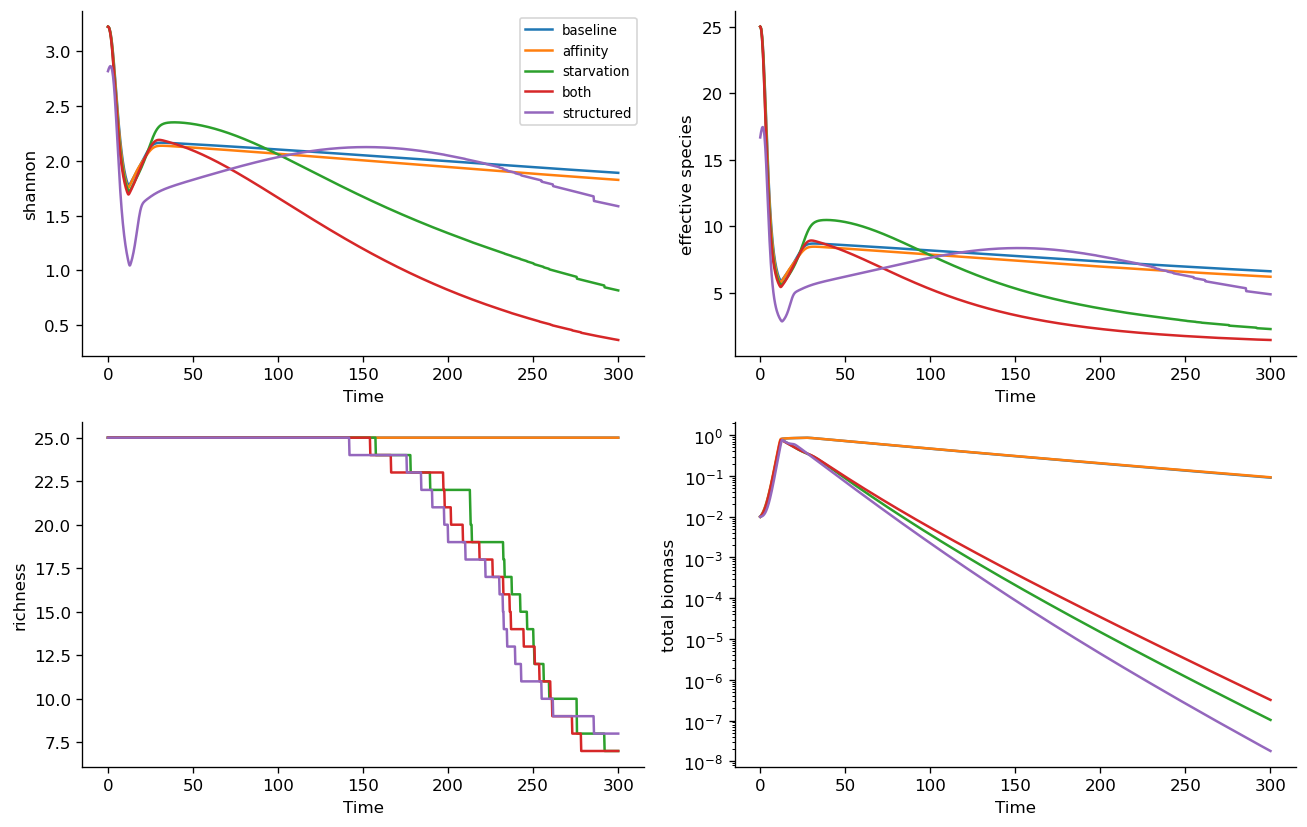

In [4]:
display(Image(filename=str(figures[0][0])))

**Figure 1. Five-scenario comparison of raw Shannon H, effective diversity exp(H), species richness and total biomass. The first four share baseline community draws; structured changes several assumptions jointly. Lower Shannon can reflect unevenness without extinction.**

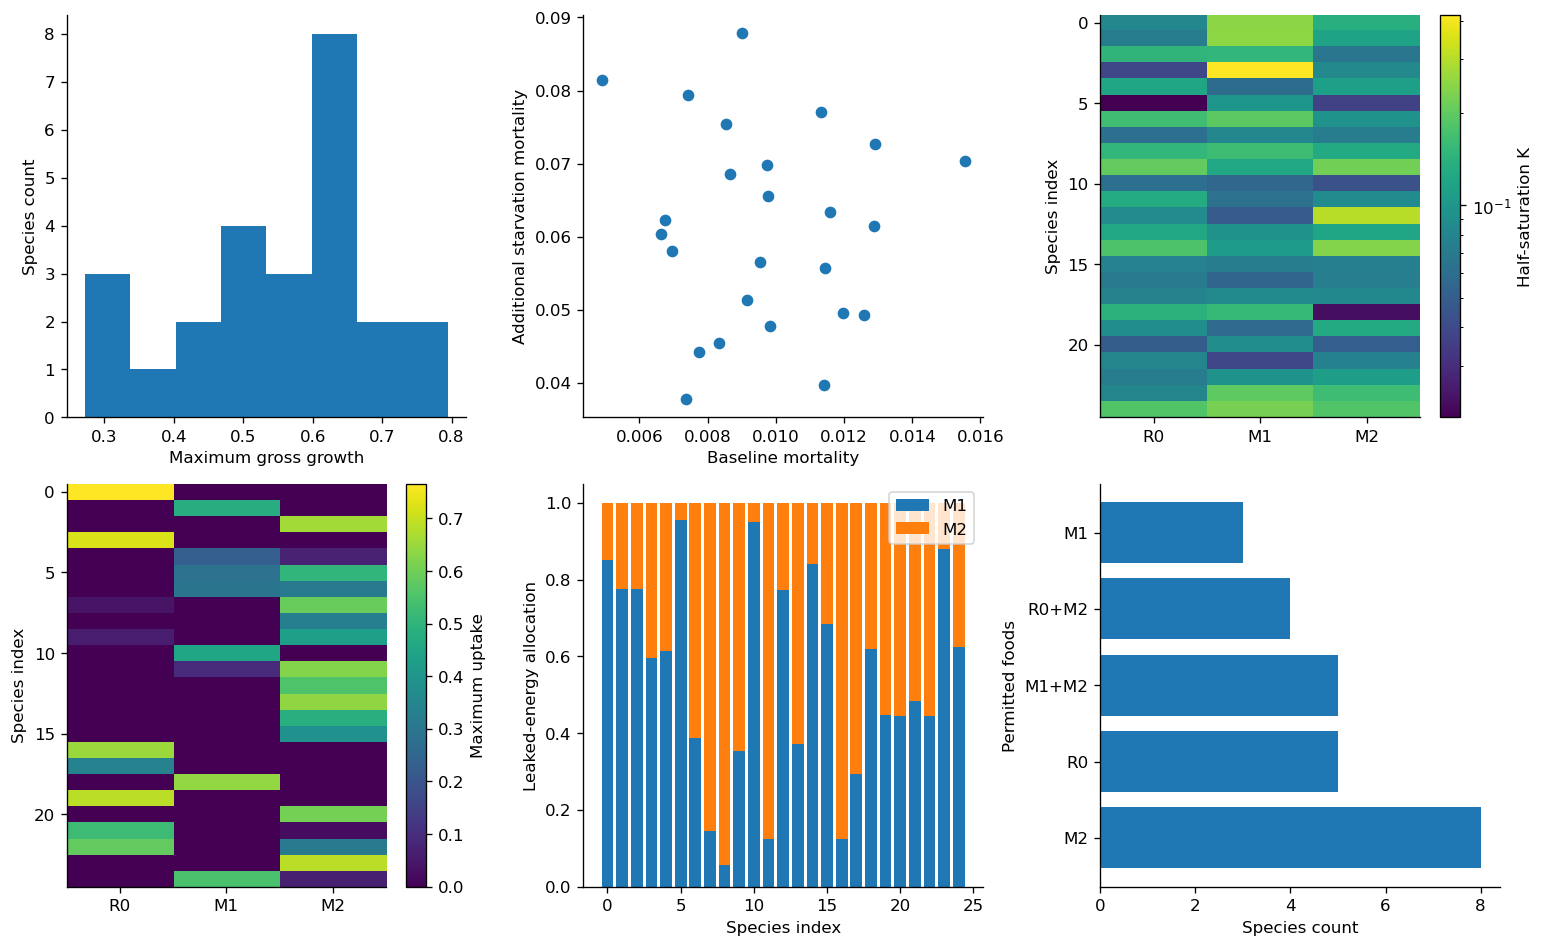

In [5]:
display(Image(filename=str(figures[1][0])))

**Figure 2. Growth capacities, basal and starvation mortality, nutrient affinities, uptake profiles, secretion shares and food permissions in the both scenario. Lower K means more efficient low-food uptake. No trait tradeoff is imposed.**

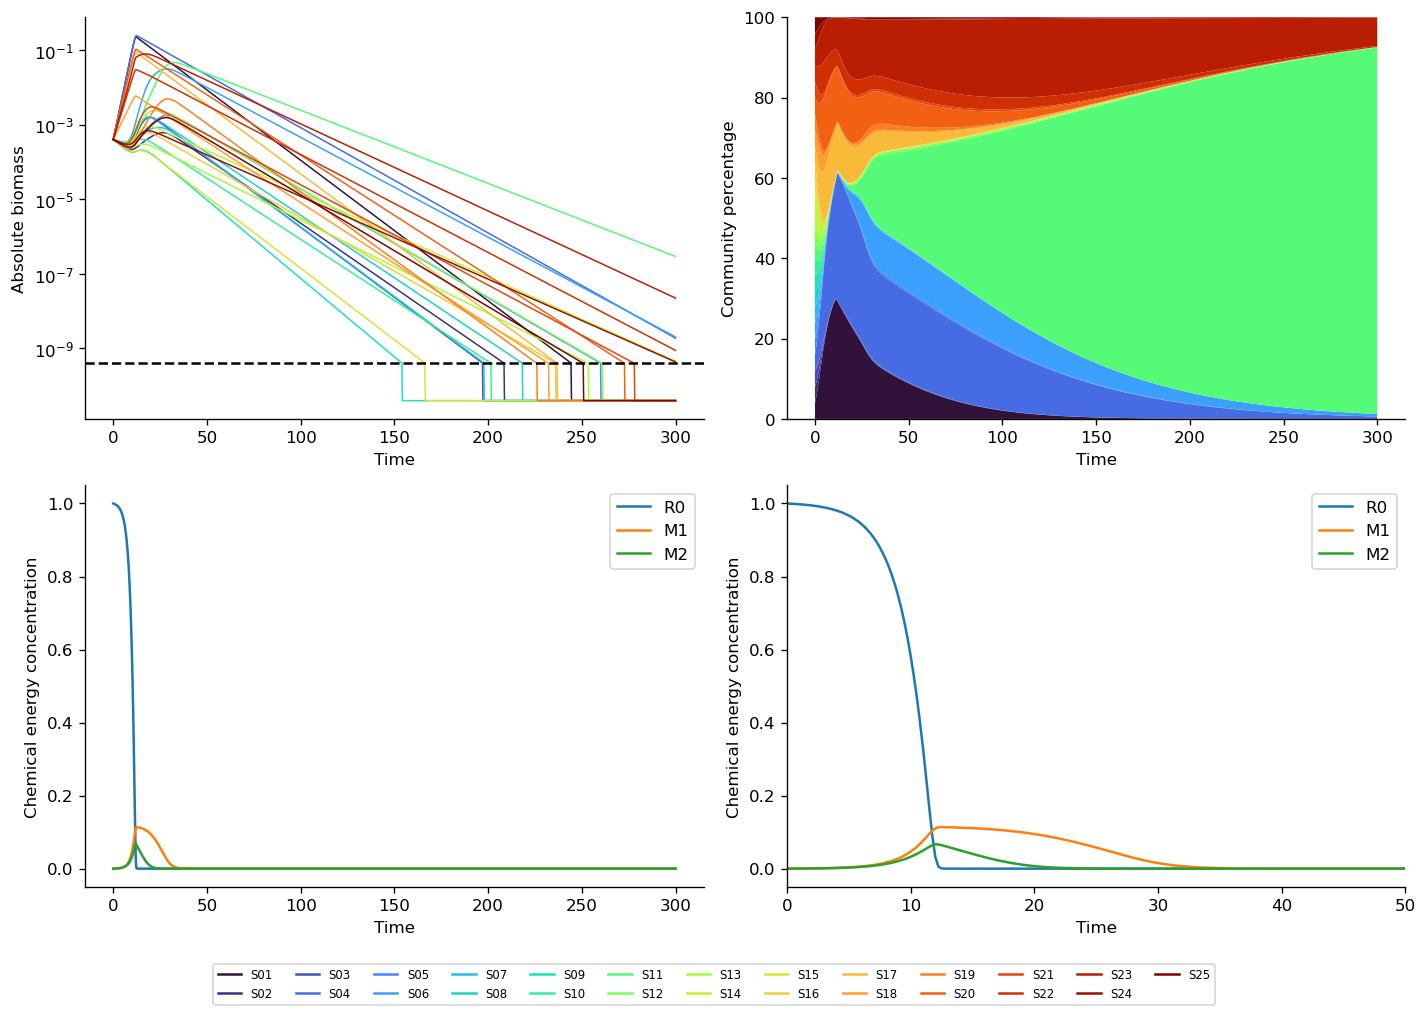

In [6]:
display(Image(filename=str(figures[2][0])))

**Figure 3A. Both scenario: absolute biomass, current community percentages, chemical pools and an early-time zoom. Species colors are consistent. Extinct species use a log-display floor; their simulated biomass is zero. A rising percentage need not mean growth.**

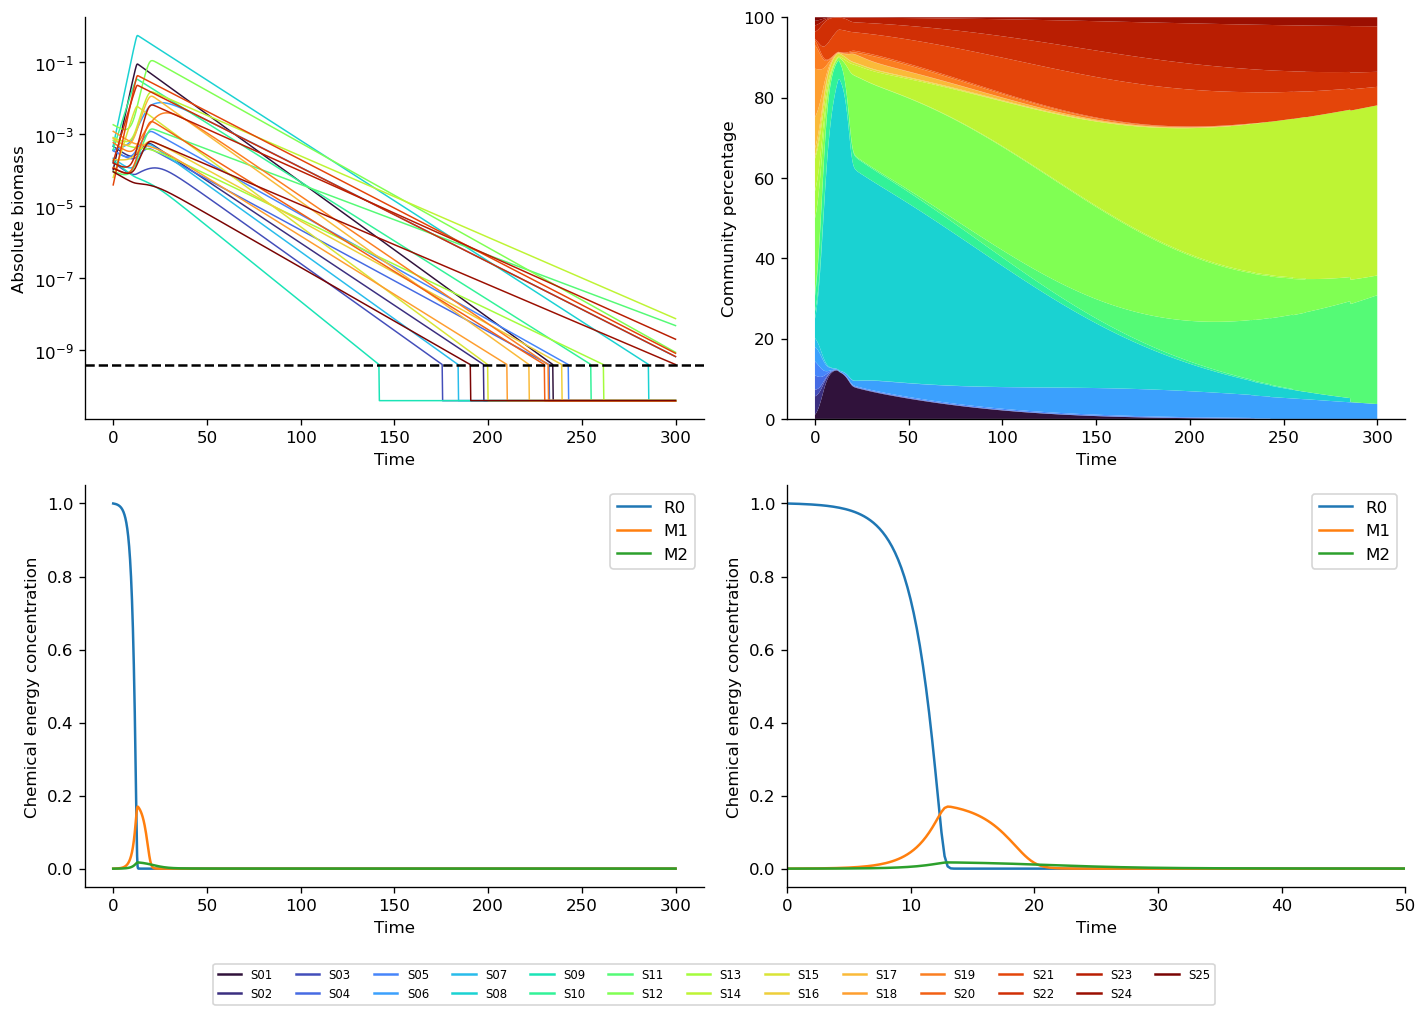

In [7]:
display(Image(filename=str(figures[3][0])))

**Figure 3B. Structured scenario: stronger specialization, varied secretion and unequal initial biomass in addition to affinity and starvation. Both metabolites initially equal zero. Because several properties change, differences from baseline do not isolate one cause.**

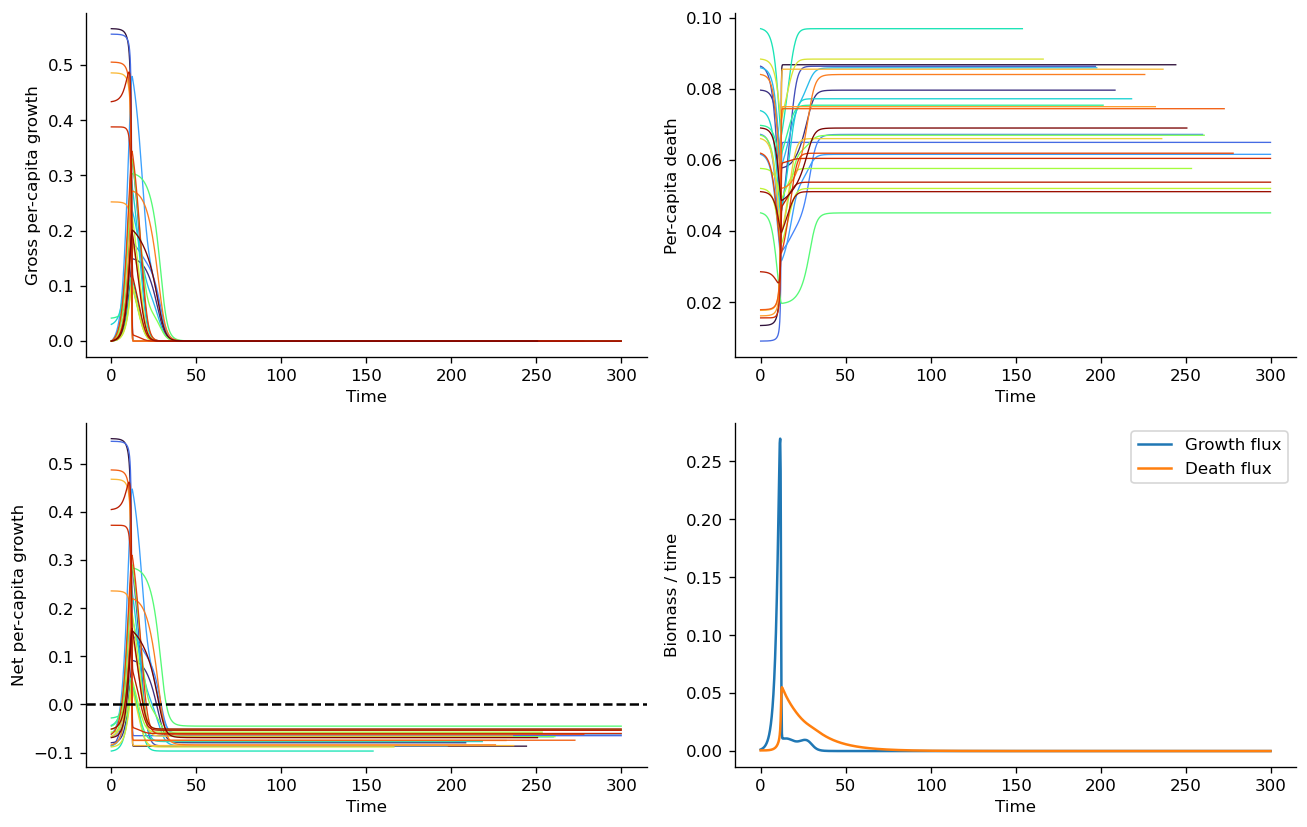

In [8]:
display(Image(filename=str(figures[4][0])))

**Figure 4. Gross growth, changing death rates, net growth and community biomass fluxes in the both scenario. Starvation raises mortality when nutrient-supported growth falls. Rates after removal are hidden. Negative net growth causes decline before extinction.**

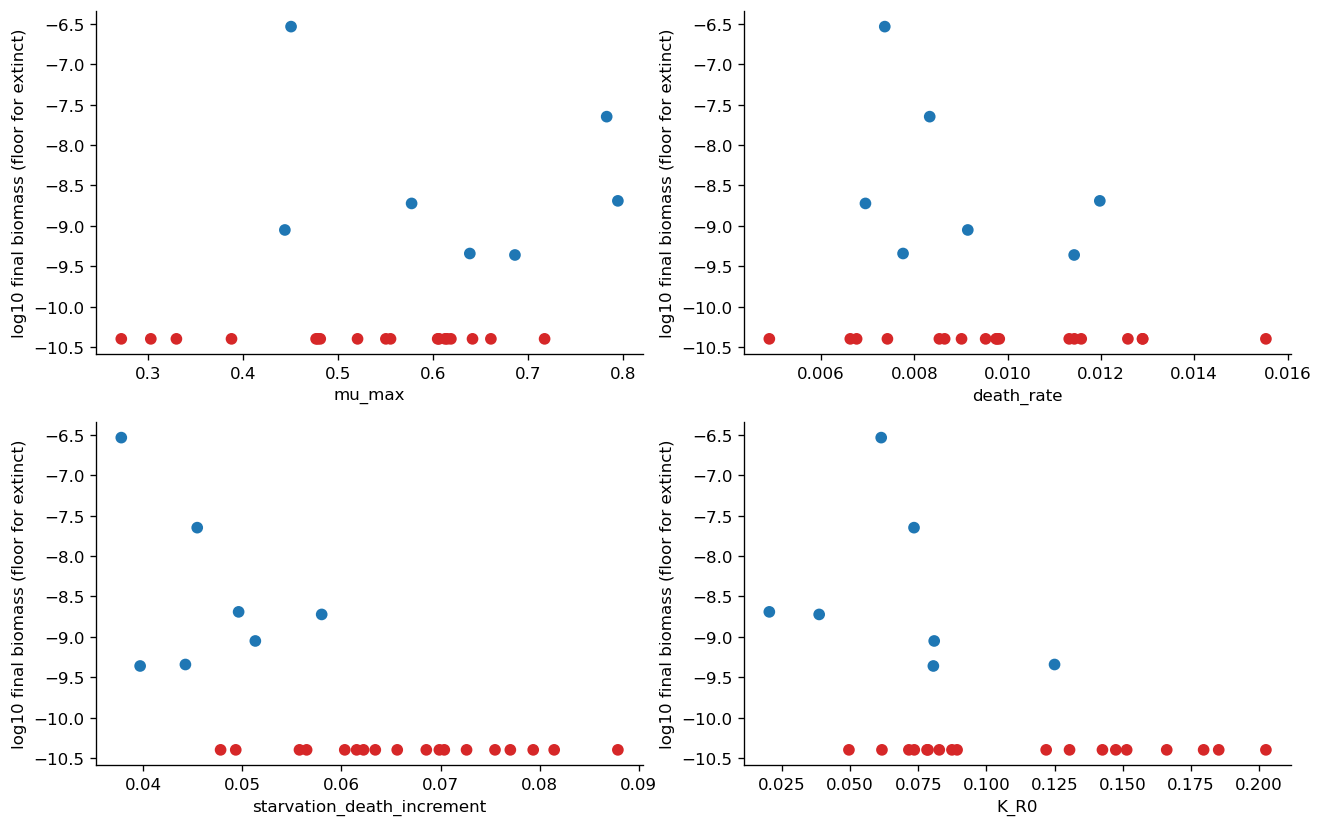

In [9]:
display(Image(filename=str(figures[5][0])))

**Figure 5. Descriptive trait associations with final biomass: blue species remain above the cutoff; red were removed. Extinct biomass appears at a plotting floor. K_R0 has no effect on a species that cannot consume R0. These associations are not causal tests.**

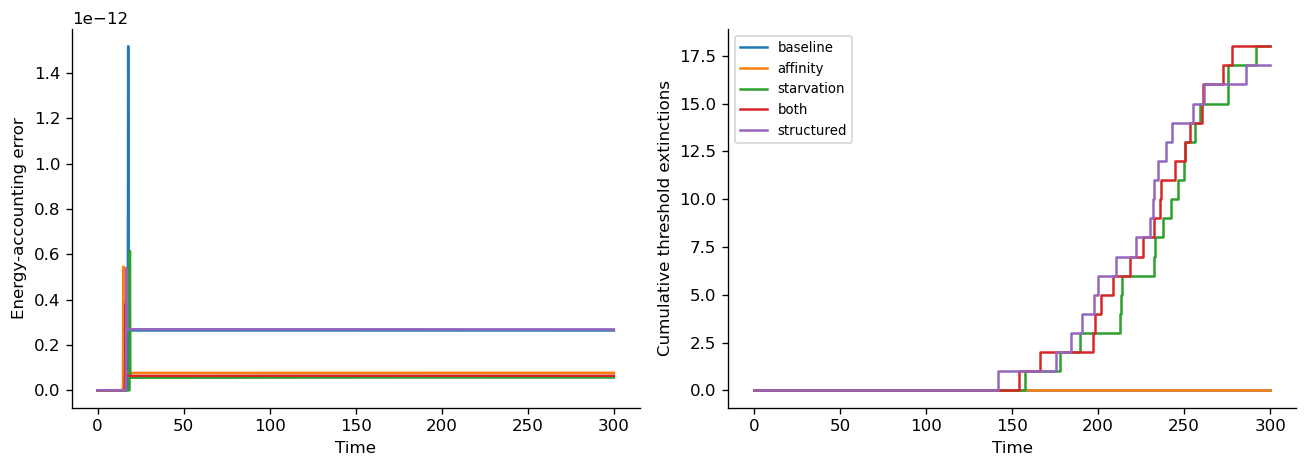

In [10]:
display(Image(filename=str(figures[6][0])))

**Figure 6. Accounting residual and cumulative irreversible cutoff crossings. Accounting includes all chemicals, living biomass, cumulative mortality and cutoff losses. Threshold extinction is a numerical definition, not a measured viability limit.**

## Extinction threshold sensitivity
Compare three cutoffs in the both condition, holding all random draws fixed. Every condition uses the same common absolute cutoff based on equal-share starting biomass.

In [11]:
from dataclasses import replace
rows=[]
for f in [1e-4,1e-6,1e-8]:
    p=model_module.generate(replace(config,extinction_fraction=f))
    r=model_module.simulate(p)
    rows.append({'cutoff_fraction':f,'survivors':int((r['N'][-1]>0).sum()),'final_biomass':r['N'][-1].sum(),'final_shannon':analysis_module.diversity(r).shannon.iloc[-1]})
sensitivity=pd.DataFrame(rows)
sensitivity.to_csv(out/'cutoff_sensitivity.csv',index=False)
display(sensitivity)

,cutoff_fraction,survivors,final_biomass,final_shannon
0,1.000000e-04,1,2.925590e-07,-0.000000
1,1.000000e-06,7,3.207641e-07,0.367401
2,1.000000e-08,14,3.210236e-07,0.375004


## Ten repeated communities
Each seed has all five conditions. Species within a community interact and should not be treated as independent replicates. The paired comparison is the community-level unit.

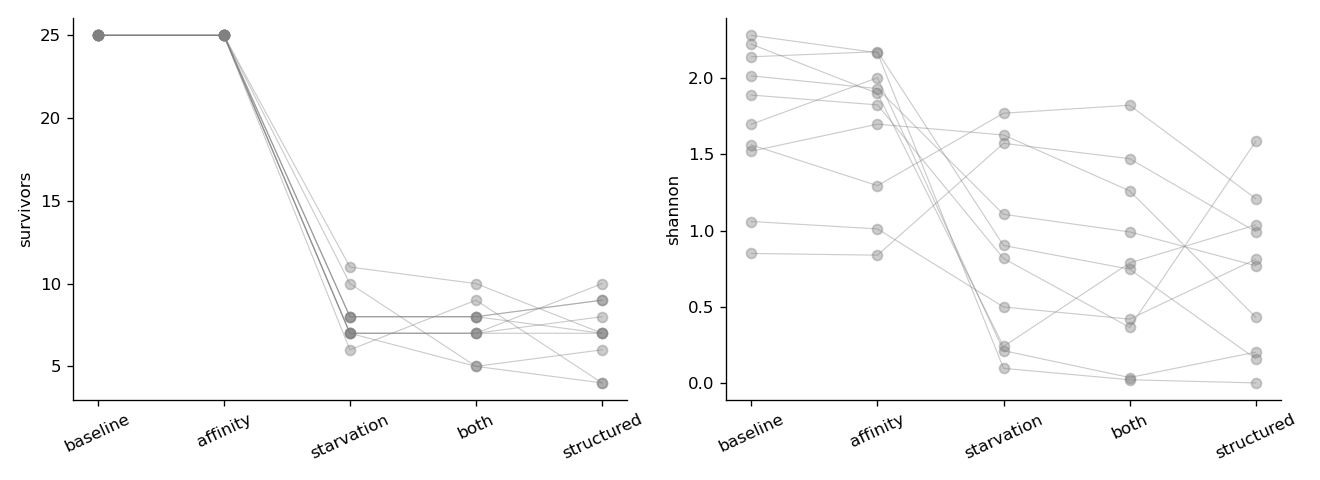

survivors   shannon
seed scenario                       
42   affinity           25  1.824486
     baseline           25  1.888597
     both                7  0.367401
     starvation          7  0.818608
     structured          8  1.584846
43   affinity           25  1.295234
     baseline           25  1.562602
     both               10  1.822033
     starvation         11  1.769923
     structured          7  1.211278
44   affinity           25  1.012408
     baseline           25  1.060643
     both                8  0.421214
     starvation          8  0.500840
     structured          7  0.813304
45   affinity           25  2.001941
     baseline           25  1.697607
     both                8  0.038962
     starvation          8  0.214811
     structured          9  0.205010
46   affinity           25  1.899545
     baseline           25  2.221744
     both                9  0.789272
     starvation          6  0.242238
     structured          4  1.038041
47   affinity           25  2.165980
     baseline           25  2.279629
     both                5  0.024290
     starvation         10  0.099031
     structured          6  0.003631
48   affinity           25  1.931172
     baseline           25  2.014485
     both                8  0.992511
     starvation          8  1.107808
     structured          9  0.771189
49   affinity           25  2.172901
     baseline           25  2.139464
     both                7  0.748483
     starvation          7  0.903765
     structured         10  0.162106
50   affinity           25  0.840226
     baseline           25  0.851419
     both                7  1.472080
     starvation          7  1.572604
     structured          7  0.994723
51   affinity           25  1.698182
     baseline           25  1.521224
     both                5  1.261508
     starvation          7  1.627248
     structured          4  0.434076

In [12]:
repeated=analysis_module.repeated_scenarios(config,replicates=10)
repeated.to_csv(out/'repeated_species_summary.csv',index=False)
repeat_path,repeat_caption=analysis_module.repeated_plot(repeated,out)
display(Image(filename=str(repeat_path)))
display(repeated.groupby(['seed','scenario']).agg(survivors=('survived','sum'),shannon=('shannon_final','first')))

**Figure 7. Each gray line connects the same random community across five conditions. Final richness and Shannon measure different aspects of community structure. The structured condition changes multiple assumptions. Simulation variation is not an experimental confidence interval.**

## Reading the results
Survival depends on time, death scale and cutoff. Variable affinity may change early dominance without sustaining growth after finite foods vanish. Starvation mortality can dominate late dynamics. Independent trait draws allow a species to be both fast-growing and high-affinity; this model does not assume a universal tradeoff. Additional extinction is not automatically evidence of greater realism. Examine absolute biomass, Shannon and percentages together.

,initial_Shannon,final_Shannon,survivors,final_total_biomass,initial_weighted_growth,final_weighted_growth,initial_weighted_baseline_death,final_weighted_baseline_death,initial_weighted_starvation_increment,final_weighted_starvation_increment
starting_community,,,,,,,,,,
Equal,3.2189,0.3674,7,0.0,0.5523,0.4774,0.0097,0.0075,0.0612,0.0386
Fast enriched,2.4976,0.6812,4,0.0,0.7005,0.5460,0.0095,0.0077,0.0553,0.0401
Slow enriched,2.2561,0.2370,7,0.0,0.3631,0.4599,0.0105,0.0074,0.0640,0.0382
Random 01,2.7913,0.3136,7,0.0,0.5284,0.4664,0.0089,0.0074,0.0583,0.0385
Random 02,1.9233,0.2350,7,0.0,0.5983,0.4584,0.0085,0.0075,0.0595,0.0381
Random 03,2.1503,0.3175,4,0.0,0.6147,0.4804,0.0086,0.0075,0.0601,0.0385
Random 04,2.2153,0.9897,5,0.0,0.6024,0.5436,0.0108,0.0080,0.0563,0.0415
Random 05,2.6961,0.6299,7,0.0,0.4993,0.4991,0.0100,0.0076,0.0606,0.0393
Random 06,2.4130,0.1559,4,0.0,0.5372,0.4593,0.0085,0.0074,0.0552,0.0381


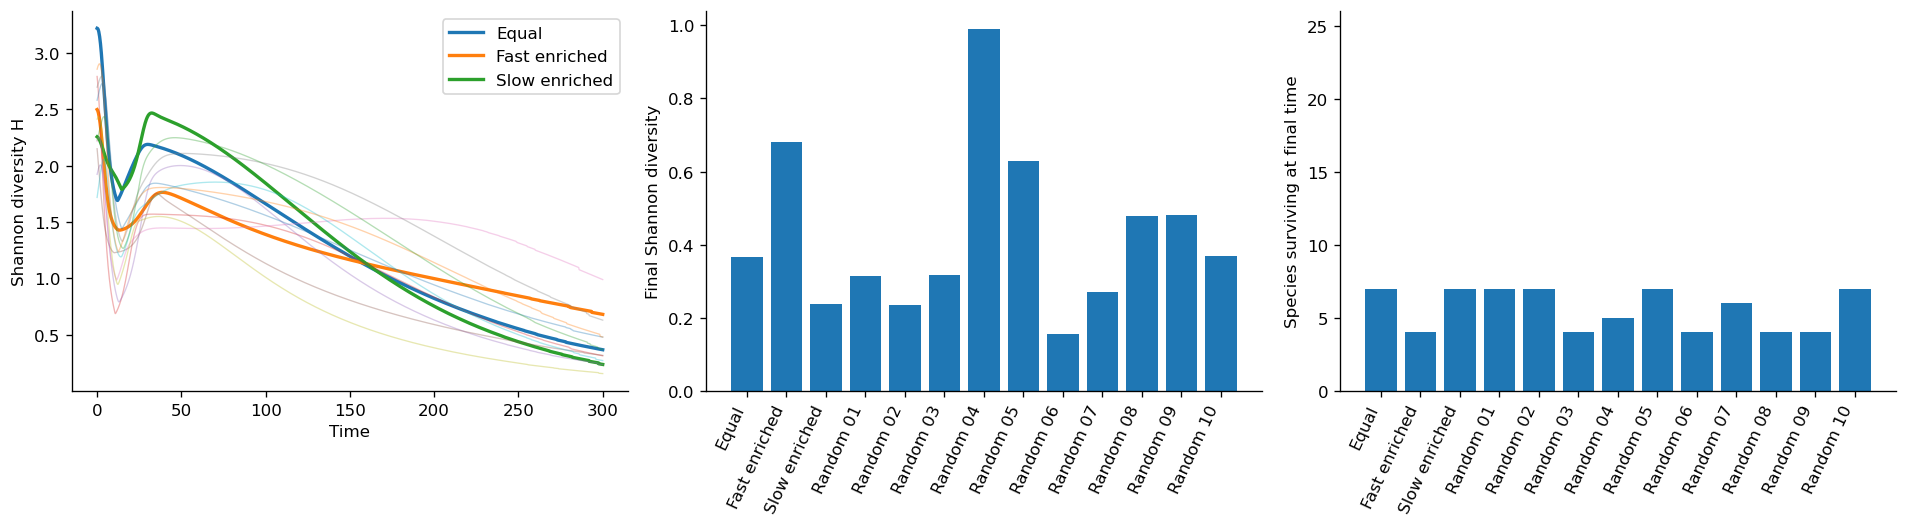


Figure 1. Starting proportions alter Shannon diversity and survival. All experiments use identical traits, total starting biomass, and food. Unequal communities already have lower initial Shannon, so interpret the trajectories together with their starting values.



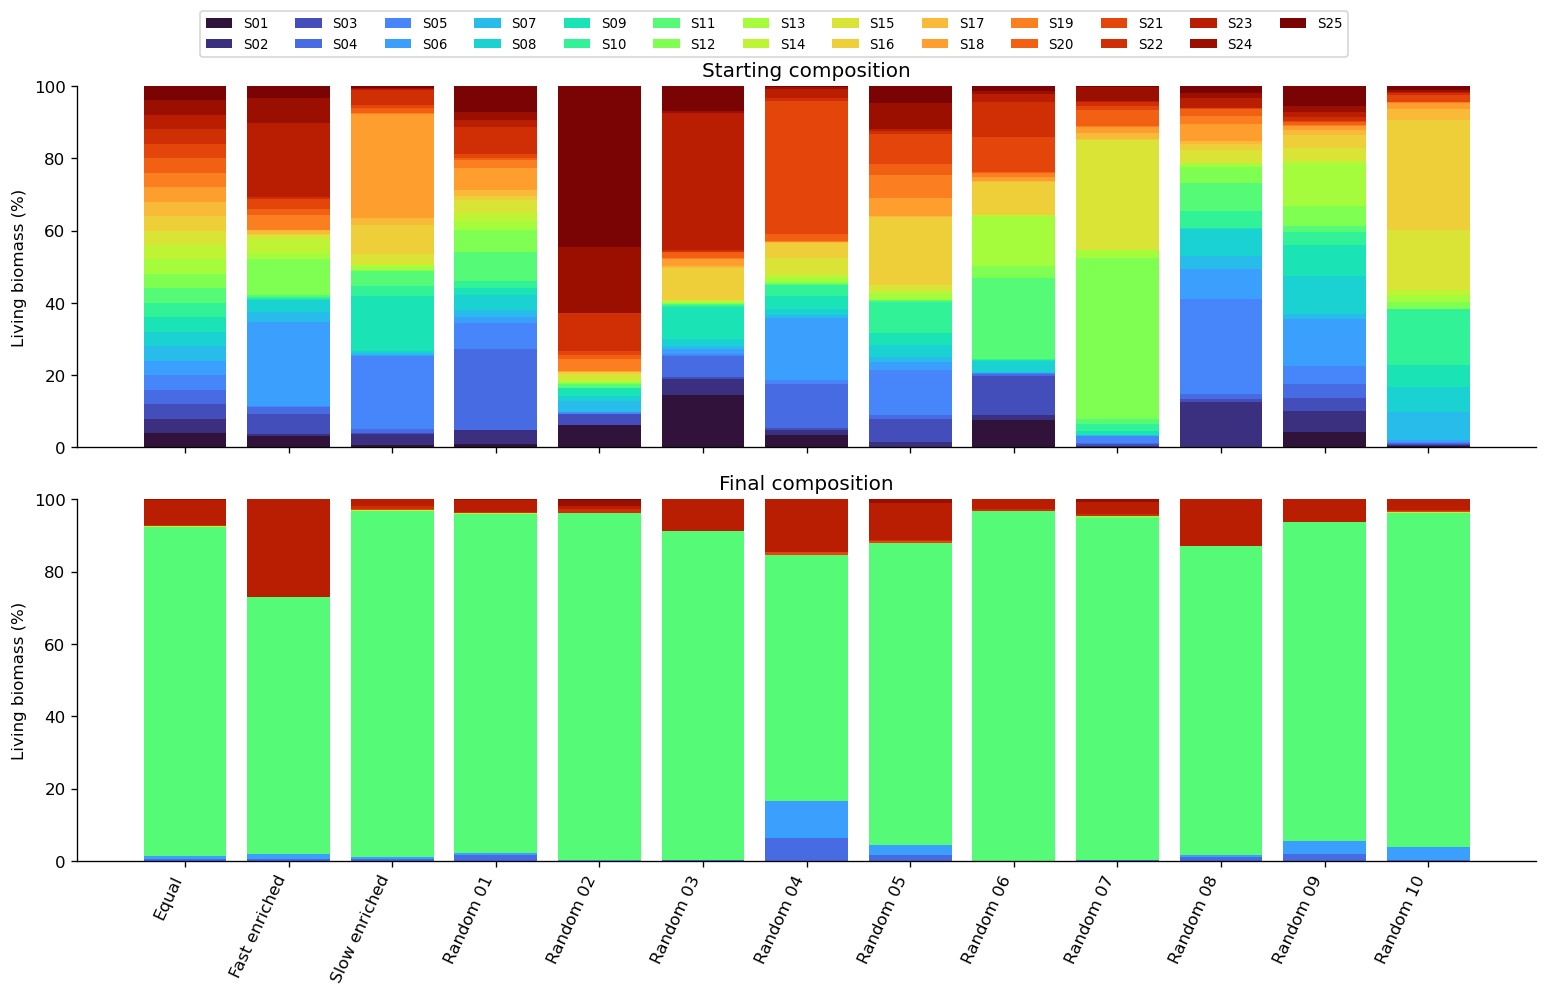


Figure 2. Each color represents the same species in both panels. Compare which starting mixtures lead to different final dominants. Percentages describe the remaining living biomass, not its absolute amount; a dominant species may still have lost biomass.



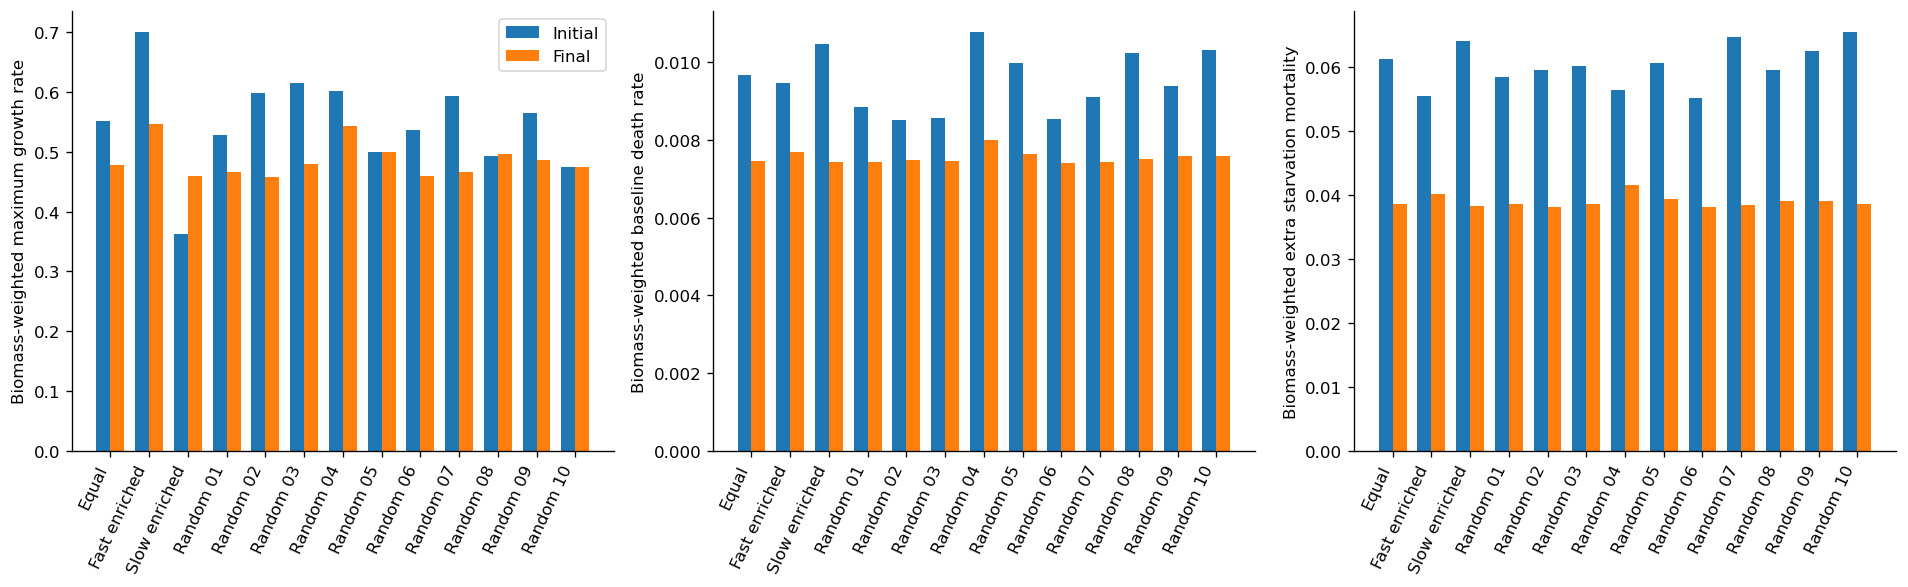


Figure 3. Community traits are weighted by species' biomass shares. A higher final weighted growth capacity indicates enrichment in fast growers, even if food depletion prevents them from growing at that rate. Baseline death and starvation increments are fixed traits; they are not the realized time-dependent death rates.



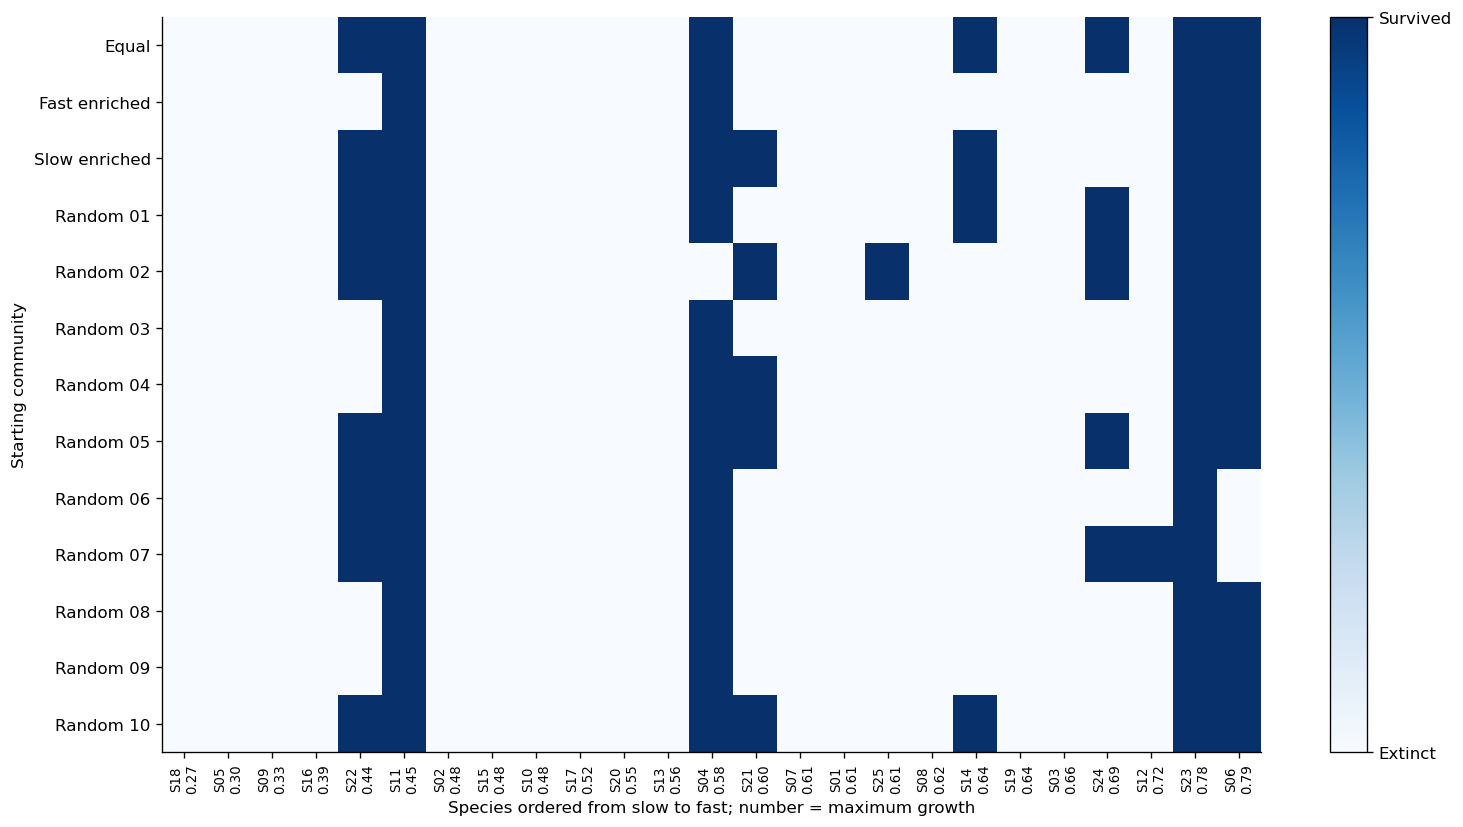


Figure 4. Dark cells indicate species above the extinction cutoff at the final time. Species are ordered by maximum growth capacity. Differences across rows show sensitivity to starting percentages; growth alone does not determine survival.



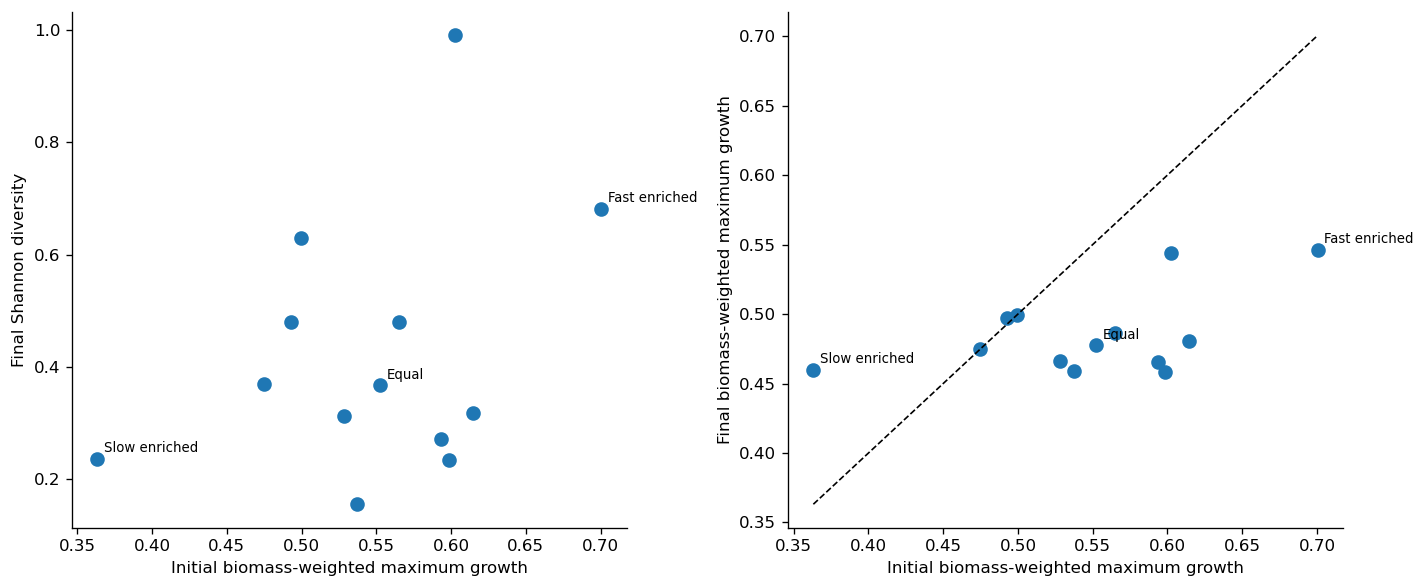


Figure 5. Left: starting growth-trait enrichment versus final Shannon. Right: points above the dashed line indicate enrichment in faster growers over the batch; points below indicate enrichment in slower growers. These comparisons use one fixed set of species, so they describe this community rather than a universal ecological rule.

Saved tables and figures to: /Users/kylie/Desktop/Duke/Classes/BME574/project/BME574/consumer_resource/batch_cr_v2/initial_composition_experiment


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace
from IPython.display import display

# Use the "both" model: variable affinity + starvation mortality.
both_config = replace(
    config,
    variable_affinity=True,
    starvation_mortality=True,
    structured_community=False,
)

template = model_module.generate(both_config)
traits = template["table"].copy()
species = traits["species"].to_numpy()
growth = traits["mu_max"].to_numpy()
n = len(species)
total_initial_biomass = both_config.initial_biomass

# Starting percentages:
# Equal = 4% each for 25 species.
# Growth-biased communities retain every species, but favor fast/slow growers.
# Random communities use different lognormal abundance mixtures.
rng = np.random.default_rng(2026)
growth_standardized = (
    (growth - growth.mean()) / max(growth.std(), 1e-12)
)

starting_shares = {
    "Equal": np.ones(n),
    "Fast enriched": np.exp(1.5 * growth_standardized),
    "Slow enriched": np.exp(-1.5 * growth_standardized),
}

for k in range(10):
    starting_shares[f"Random {k + 1:02d}"] = rng.lognormal(
        mean=0, sigma=1.5, size=n
    )

starting_shares = {
    name: weights / weights.sum()
    for name, weights in starting_shares.items()
}

results = {}
summary_rows = []
species_rows = []

for name, shares in starting_shares.items():
    # Same seed gives exactly the same traits in every experiment.
    community = model_module.generate(both_config)

    # Only change initial biomass allocation.
    initial = total_initial_biomass * shares
    community["initial"] = initial.copy()
    community["table"]["initial_biomass"] = initial

    result = model_module.simulate(community)
    diversity = analysis_module.diversity(result)

    final = result["N"][-1]
    final_total = final.sum()
    final_shares = (
        final / final_total
        if final_total > 0
        else np.full(n, np.nan)
    )
    survived = np.isnan(result["extinction"])

    results[name] = {
        "initial_shares": shares,
        "final_shares": final_shares,
        "survived": survived,
        "simulation": result,
        "diversity": diversity,
    }

    summary_rows.append({
        "starting_community": name,
        "initial_Shannon": diversity["shannon"].iloc[0],
        "final_Shannon": diversity["shannon"].iloc[-1],
        "survivors": int(survived.sum()),
        "final_total_biomass": final_total,
        "initial_weighted_growth": shares @ growth,
        "final_weighted_growth": (
            final_shares @ growth if final_total > 0 else np.nan
        ),
        "initial_weighted_baseline_death":
            shares @ traits["death_rate"].to_numpy(),
        "final_weighted_baseline_death": (
            final_shares @ traits["death_rate"].to_numpy()
            if final_total > 0 else np.nan
        ),
        "initial_weighted_starvation_increment":
            shares @ traits["starvation_death_increment"].to_numpy(),
        "final_weighted_starvation_increment": (
            final_shares @ traits["starvation_death_increment"].to_numpy()
            if final_total > 0 else np.nan
        ),
    })

    species_table = traits.copy()
    species_table["starting_community"] = name
    species_table["initial_percent"] = 100 * shares
    species_table["final_percent"] = 100 * final_shares
    species_table["final_biomass"] = final
    species_table["survived"] = survived
    species_table["extinction_time"] = result["extinction"]
    species_rows.append(species_table)

summary = pd.DataFrame(summary_rows).set_index("starting_community")
species_outcomes = pd.concat(species_rows, ignore_index=True)

display(summary.round(4))

# Save tables and figures.
save_folder = Path("initial_composition_experiment")
save_folder.mkdir(exist_ok=True)
summary.to_csv(save_folder / "community_summary.csv")
species_outcomes.to_csv(
    save_folder / "species_traits_and_outcomes.csv", index=False
)

def caption(text):
    print("\n" + text + "\n")

def finish_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(save_folder / filename, dpi=180, bbox_inches="tight")
    plt.show()

names = list(results)
x = np.arange(len(names))

# 1. Shannon trajectories and final outcomes.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for name in names:
    d = results[name]["diversity"]
    highlighted = name in ["Equal", "Fast enriched", "Slow enriched"]
    axes[0].plot(
        d["time"], d["shannon"],
        linewidth=2 if highlighted else 0.8,
        alpha=1 if highlighted else 0.35,
        label=name if highlighted else None,
    )

axes[0].set(xlabel="Time", ylabel="Shannon diversity H")
axes[0].legend()

axes[1].bar(x, summary["final_Shannon"])
axes[1].set(ylabel="Final Shannon diversity")

axes[2].bar(x, summary["survivors"])
axes[2].set(ylabel="Species surviving at final time", ylim=(0, n + 1))

for ax in axes[1:]:
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=65, ha="right")

finish_figure(fig, "01_shannon_and_survival.png")
caption(
    "Figure 1. Starting proportions alter Shannon diversity and survival. "
    "All experiments use identical traits, total starting biomass, and food. "
    "Unequal communities already have lower initial Shannon, so interpret "
    "the trajectories together with their starting values."
)

# 2. Starting and final community composition.
initial_matrix = np.array([
    results[name]["initial_shares"] for name in names
])
final_matrix = np.array([
    results[name]["final_shares"] for name in names
])

colors = plt.cm.turbo(np.linspace(0, 1, n))
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for ax, matrix, title in zip(
    axes,
    [initial_matrix, final_matrix],
    ["Starting composition", "Final composition"],
):
    bottom = np.zeros(len(names))
    for i in range(n):
        values = 100 * matrix[:, i]
        ax.bar(x, values, bottom=bottom, color=colors[i],
               label=species[i])
        bottom += np.nan_to_num(values)
    ax.set(title=title, ylabel="Living biomass (%)", ylim=(0, 100))

axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=65, ha="right")
fig.legend(
    handles=axes[0].get_legend_handles_labels()[0],
    labels=species.tolist(),
    loc="upper center", bbox_to_anchor=(0.5, 1.04),
    ncol=13, fontsize=8,
)
finish_figure(fig, "02_initial_final_composition.png")
caption(
    "Figure 2. Each color represents the same species in both panels. "
    "Compare which starting mixtures lead to different final dominants. "
    "Percentages describe the remaining living biomass, not its absolute "
    "amount; a dominant species may still have lost biomass."
)

# 3. Biomass-weighted community traits.
trait_columns = [
    ("growth", "Maximum growth rate"),
    ("baseline_death", "Baseline death rate"),
    ("starvation_increment", "Extra starvation mortality"),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (column, label) in zip(axes, trait_columns):
    ax.bar(
        x - 0.18, summary[f"initial_weighted_{column}"],
        width=0.36, label="Initial",
    )
    ax.bar(
        x + 0.18, summary[f"final_weighted_{column}"],
        width=0.36, label="Final",
    )
    ax.set(ylabel=f"Biomass-weighted {label.lower()}")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=65, ha="right")

axes[0].legend()
finish_figure(fig, "03_community_trait_enrichment.png")
caption(
    "Figure 3. Community traits are weighted by species' biomass shares. "
    "A higher final weighted growth capacity indicates enrichment in fast "
    "growers, even if food depletion prevents them from growing at that "
    "rate. Baseline death and starvation increments are fixed traits; "
    "they are not the realized time-dependent death rates."
)

# 4. Which species survived? Order species by growth capacity.
order = np.argsort(growth)
survival_matrix = np.array([
    results[name]["survived"] for name in names
], dtype=int)[:, order]

fig, ax = plt.subplots(figsize=(13, 7))
image = ax.imshow(
    survival_matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1
)
ax.set_xticks(np.arange(n))
ax.set_xticklabels(
    [f"{species[i]}\n{growth[i]:.2f}" for i in order],
    rotation=90, fontsize=8,
)
ax.set_yticks(x)
ax.set_yticklabels(names)
ax.set(
    xlabel="Species ordered from slow to fast; number = maximum growth",
    ylabel="Starting community",
)
bar = fig.colorbar(image, ax=ax, ticks=[0, 1])
bar.ax.set_yticklabels(["Extinct", "Survived"])
finish_figure(fig, "04_species_survival.png")
caption(
    "Figure 4. Dark cells indicate species above the extinction cutoff "
    "at the final time. Species are ordered by maximum growth capacity. "
    "Differences across rows show sensitivity to starting percentages; "
    "growth alone does not determine survival."
)

# 5. Are fast or slow growers enriched overall?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    summary["initial_weighted_growth"],
    summary["final_Shannon"], s=60,
)
axes[0].set(
    xlabel="Initial biomass-weighted maximum growth",
    ylabel="Final Shannon diversity",
)

axes[1].scatter(
    summary["initial_weighted_growth"],
    summary["final_weighted_growth"], s=60,
)
low = min(
    summary["initial_weighted_growth"].min(),
    summary["final_weighted_growth"].min(),
)
high = max(
    summary["initial_weighted_growth"].max(),
    summary["final_weighted_growth"].max(),
)
axes[1].plot([low, high], [low, high], "k--", linewidth=1)
axes[1].set(
    xlabel="Initial biomass-weighted maximum growth",
    ylabel="Final biomass-weighted maximum growth",
)

for name in ["Equal", "Fast enriched", "Slow enriched"]:
    row = summary.loc[name]
    axes[0].annotate(
        name, (row["initial_weighted_growth"], row["final_Shannon"]),
        xytext=(4, 4), textcoords="offset points", fontsize=8,
    )
    axes[1].annotate(
        name,
        (row["initial_weighted_growth"], row["final_weighted_growth"]),
        xytext=(4, 4), textcoords="offset points", fontsize=8,
    )

finish_figure(fig, "05_growth_enrichment_and_diversity.png")
caption(
    "Figure 5. Left: starting growth-trait enrichment versus final Shannon. "
    "Right: points above the dashed line indicate enrichment in faster "
    "growers over the batch; points below indicate enrichment in slower "
    "growers. These comparisons use one fixed set of species, so they "
    "describe this community rather than a universal ecological rule."
)

print(f"Saved tables and figures to: {save_folder.resolve()}")